# CRLD observability flow grids — **memory-3**

Same six-panel observability grids as the memory-1 notebook, but here every agent
conditions on the **last 3 rounds** (`HistoryEmbedded h=(3,…)`), so the
underlying state space is $(2^N)^{3}$. The flow is drawn in the state where every
agent cooperated in *all 3* remembered rounds.

**A note on agent pairs.** All agents are **homogeneous** (the same observability
regime is applied to every agent) and the game is symmetric, so agent 0 ≡ agent 1 ≡
… statistically — every agent-pair projection looks the same. We therefore plot a
single representative pair (**agent 0 vs agent 1**). (Heterogeneous agents — a
different regime per agent — would make the pairs genuinely differ; that is a
separate experiment.)

Axes / reading: arrows = where the learning rule pushes the joint policy; purple =
trajectories; (0,0) = mutual defection, (1,1) = mutual cooperation.

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib import image as mpimg
plt.rcParams.update({"figure.dpi": 130})
RESULTS = os.path.join(os.getcwd(), "results")
def show(fname, title, figsize=(13, 8)):
    p = os.path.join(RESULTS, fname)
    if not os.path.exists(p):
        print("(not generated:", fname, ")"); return
    fig, ax = plt.subplots(figsize=figsize); ax.imshow(mpimg.imread(p)); ax.axis("off")
    ax.set_title(title, fontsize=11, loc="left", color="#114"); plt.show()


## Prisoner's Dilemma (IPD)

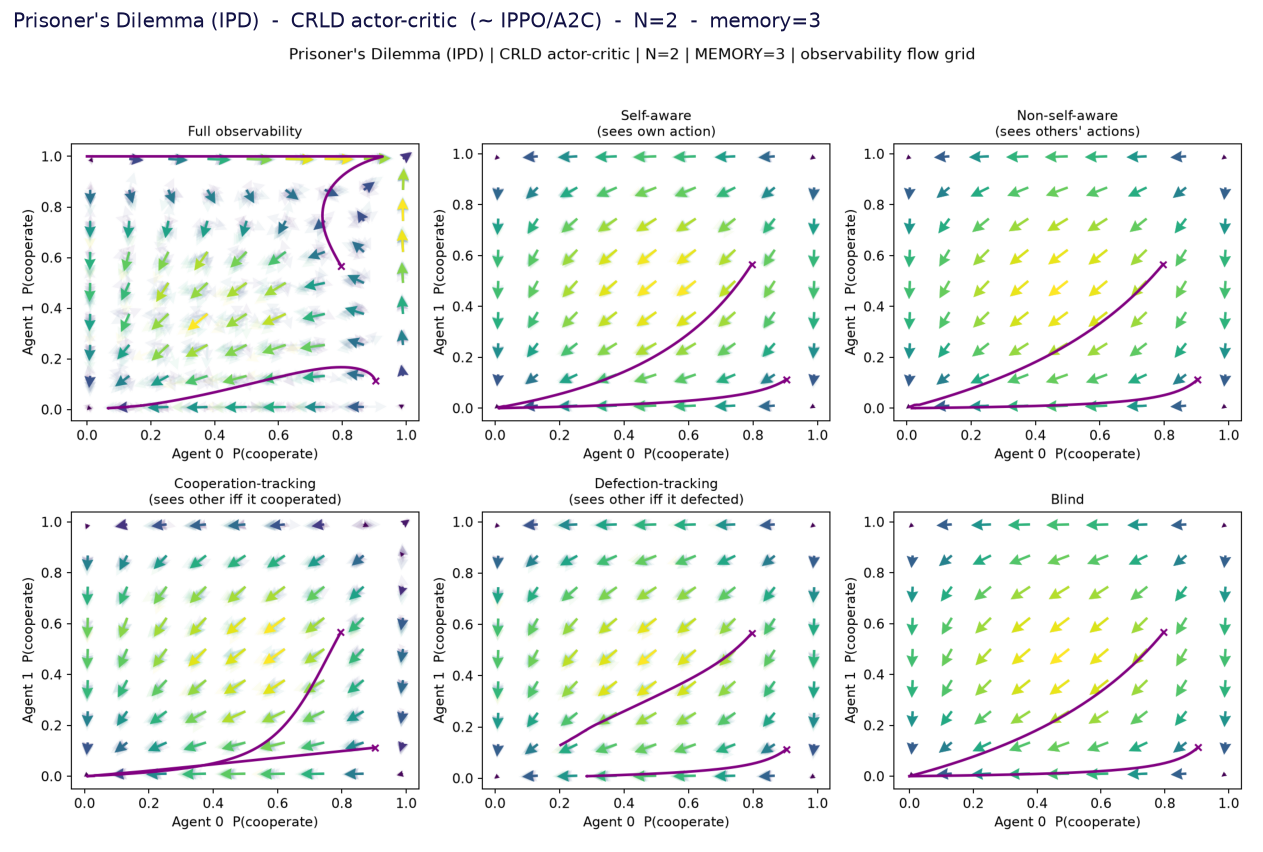

In [2]:
show('memgrid_m3_ipd_ac_N2.png', "Prisoner's Dilemma (IPD)  -  CRLD actor-critic  (~ IPPO/A2C)  -  N=2  -  memory=3")

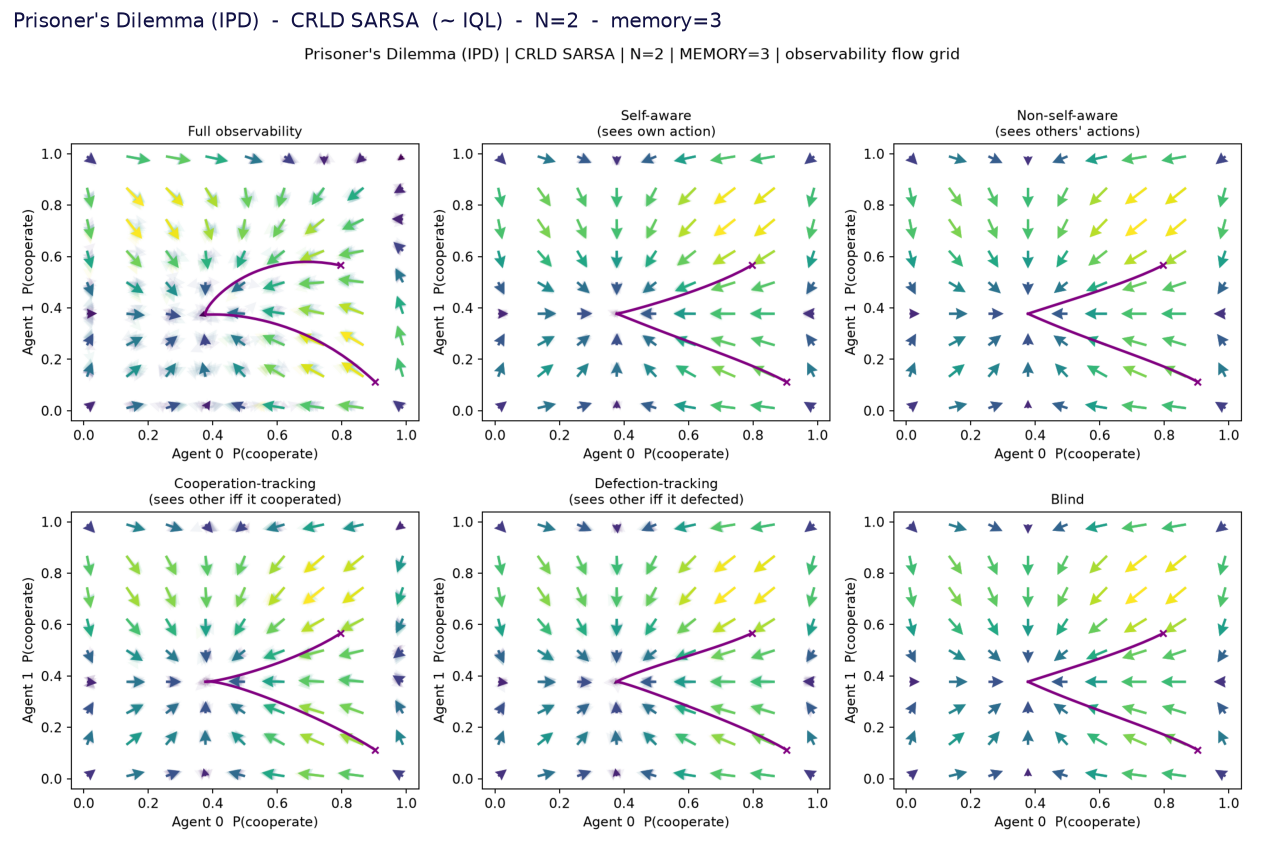

In [3]:
show('memgrid_m3_ipd_sarsa_N2.png', "Prisoner's Dilemma (IPD)  -  CRLD SARSA  (~ IQL)  -  N=2  -  memory=3")

## Harmony

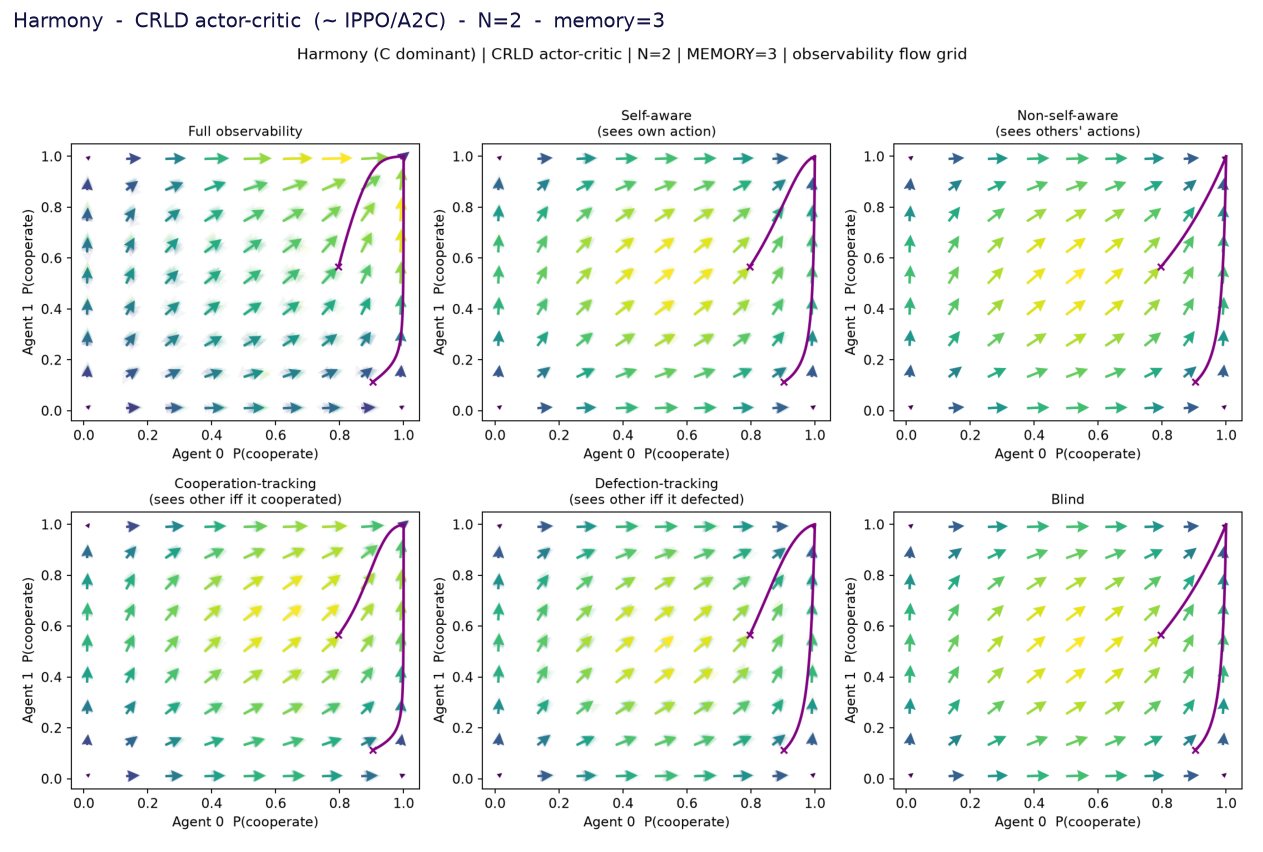

In [4]:
show('memgrid_m3_harmony_ac_N2.png', 'Harmony  -  CRLD actor-critic  (~ IPPO/A2C)  -  N=2  -  memory=3')

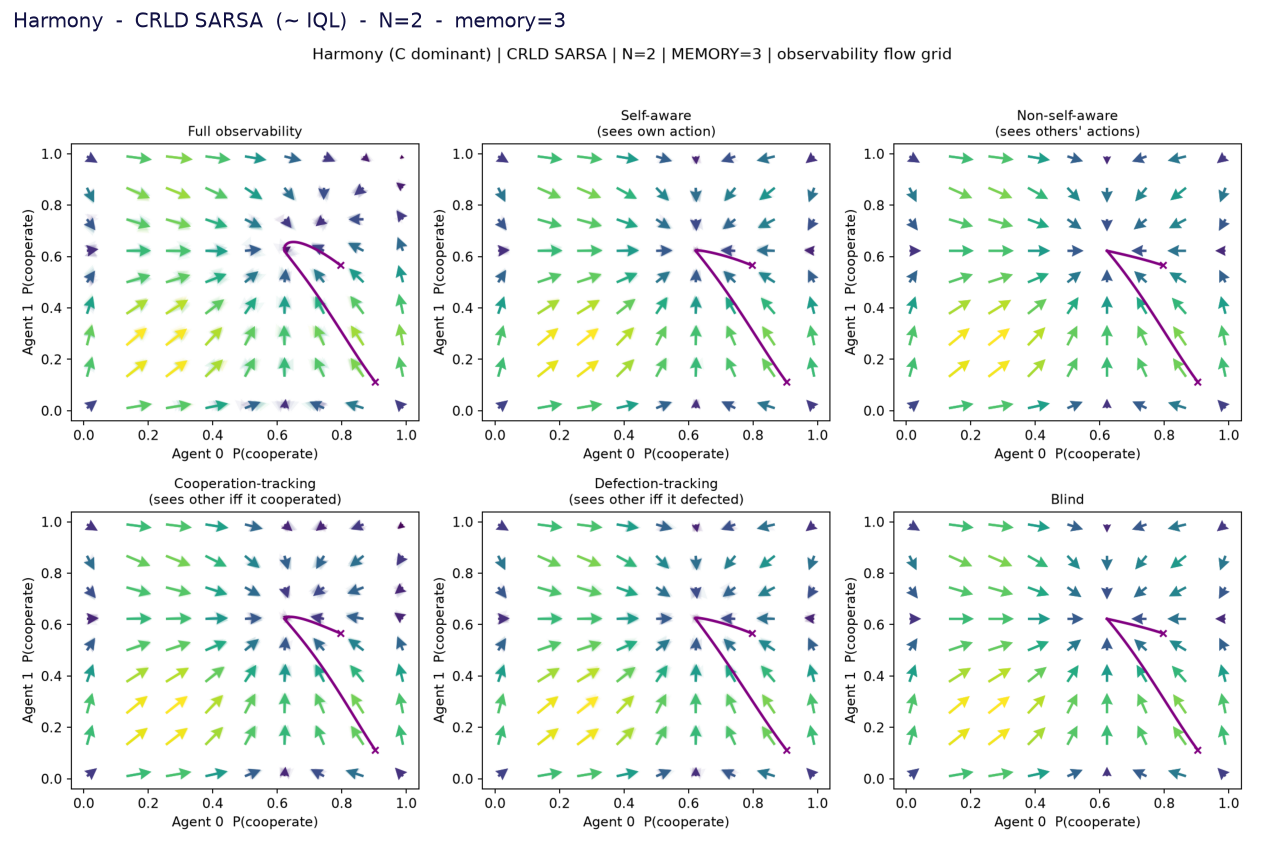

In [5]:
show('memgrid_m3_harmony_sarsa_N2.png', 'Harmony  -  CRLD SARSA  (~ IQL)  -  N=2  -  memory=3')

## Stag Hunt

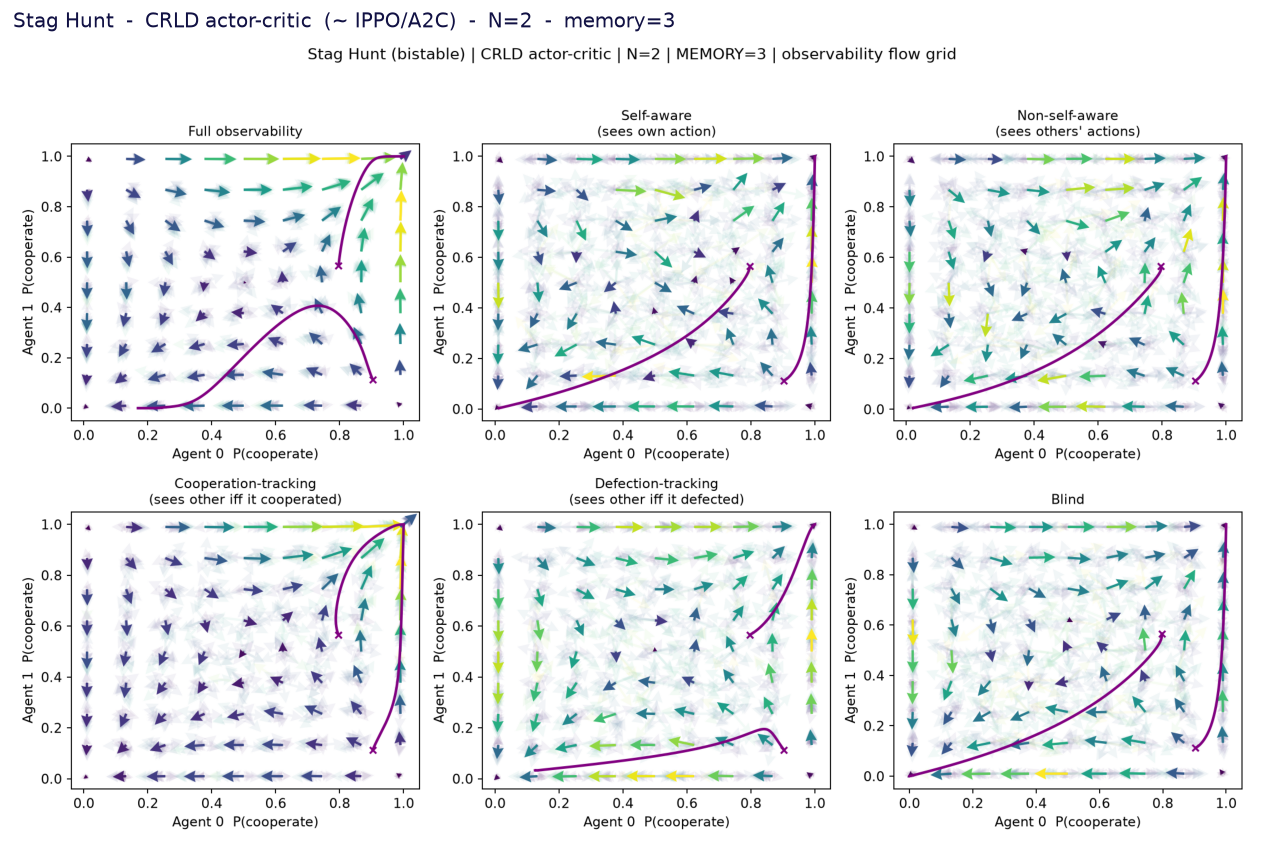

In [6]:
show('memgrid_m3_staghunt_ac_N2.png', 'Stag Hunt  -  CRLD actor-critic  (~ IPPO/A2C)  -  N=2  -  memory=3')

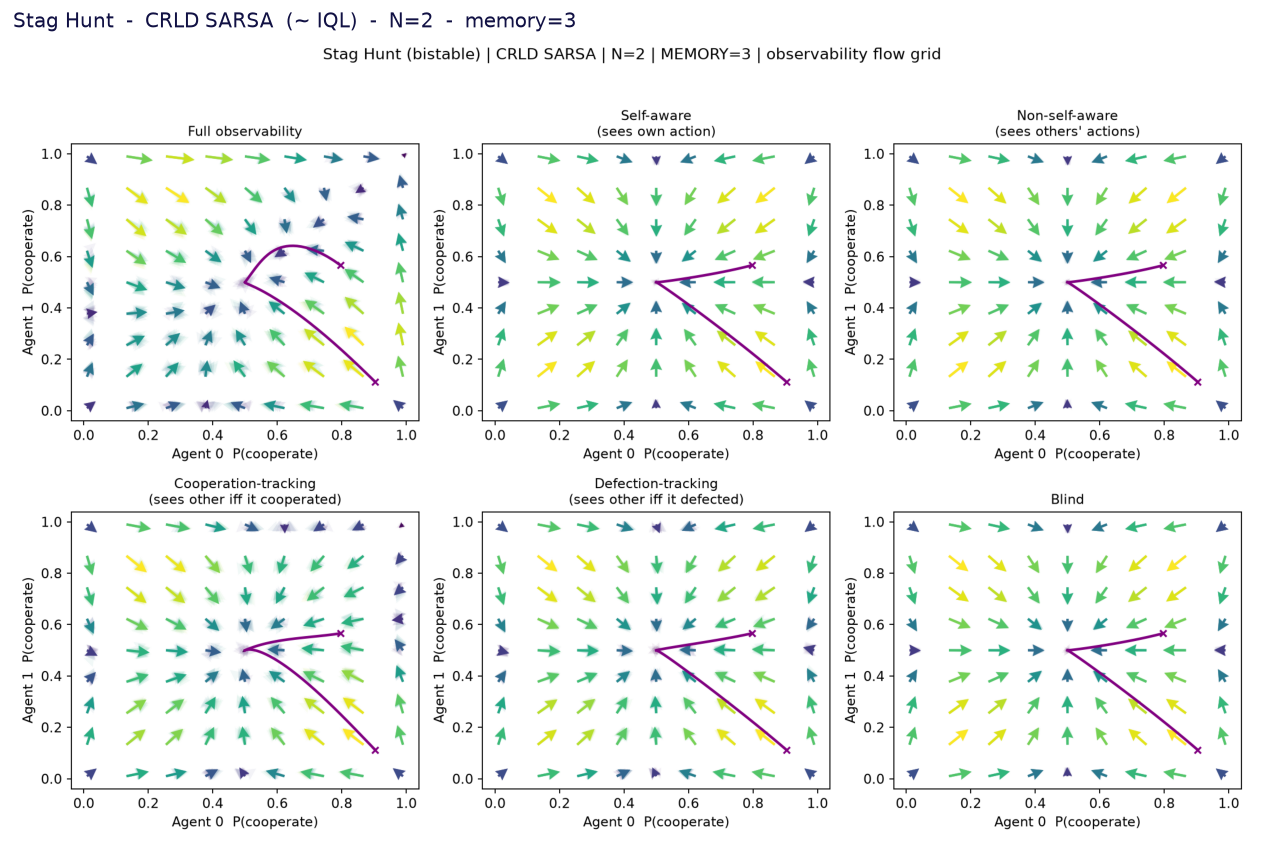

In [7]:
show('memgrid_m3_staghunt_sarsa_N2.png', 'Stag Hunt  -  CRLD SARSA  (~ IQL)  -  N=2  -  memory=3')

## Snowdrift / Chicken

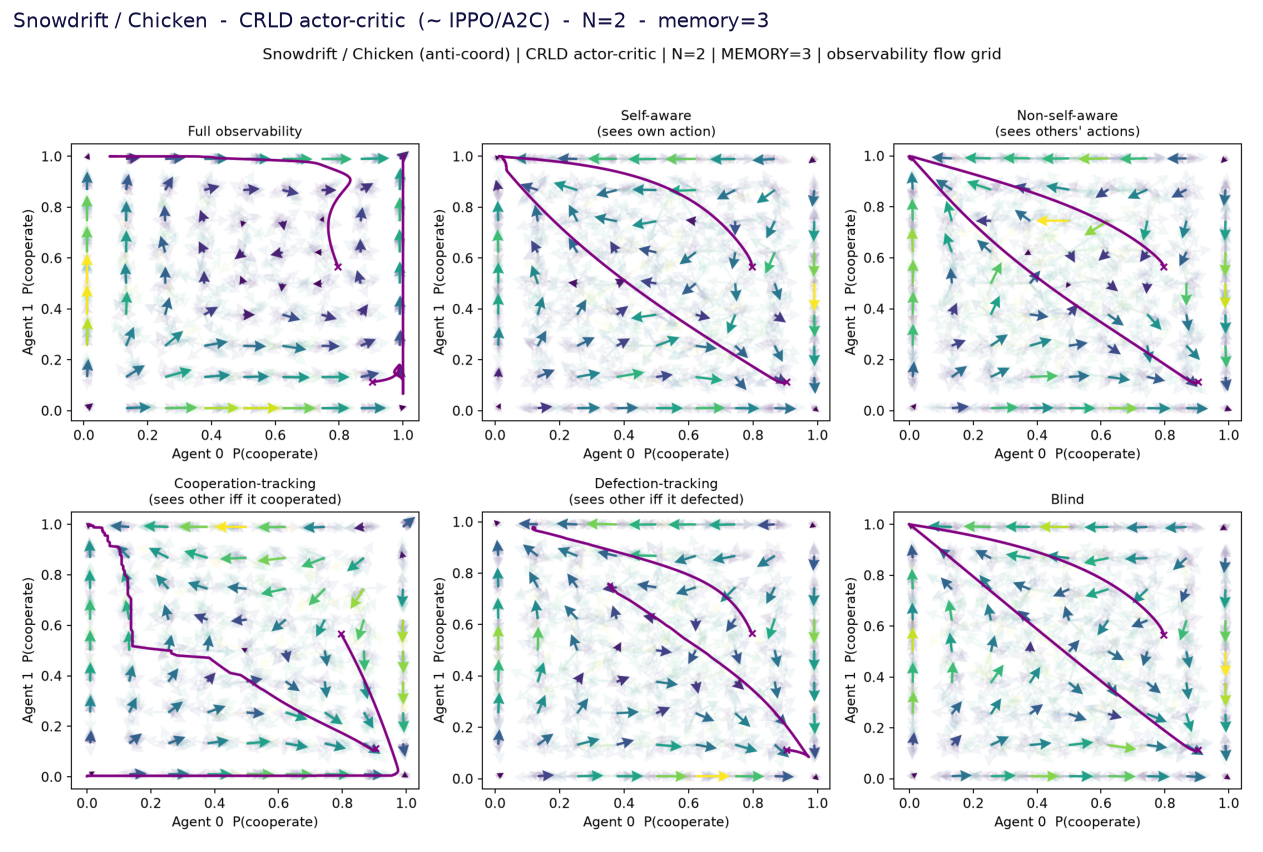

In [8]:
show('memgrid_m3_snowdrift_ac_N2.png', 'Snowdrift / Chicken  -  CRLD actor-critic  (~ IPPO/A2C)  -  N=2  -  memory=3')

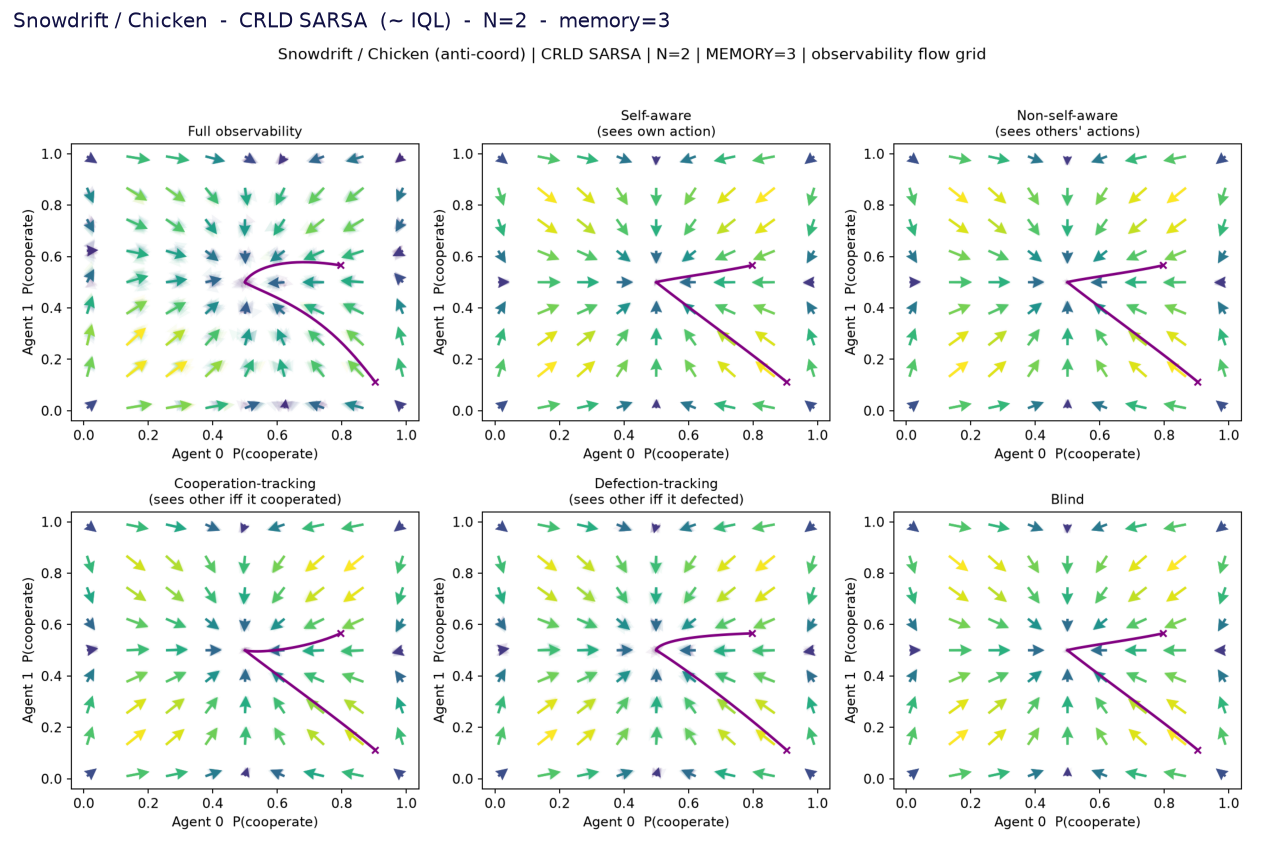

In [9]:
show('memgrid_m3_snowdrift_sarsa_N2.png', 'Snowdrift / Chicken  -  CRLD SARSA  (~ IQL)  -  N=2  -  memory=3')

## coin_game (PD reduction)

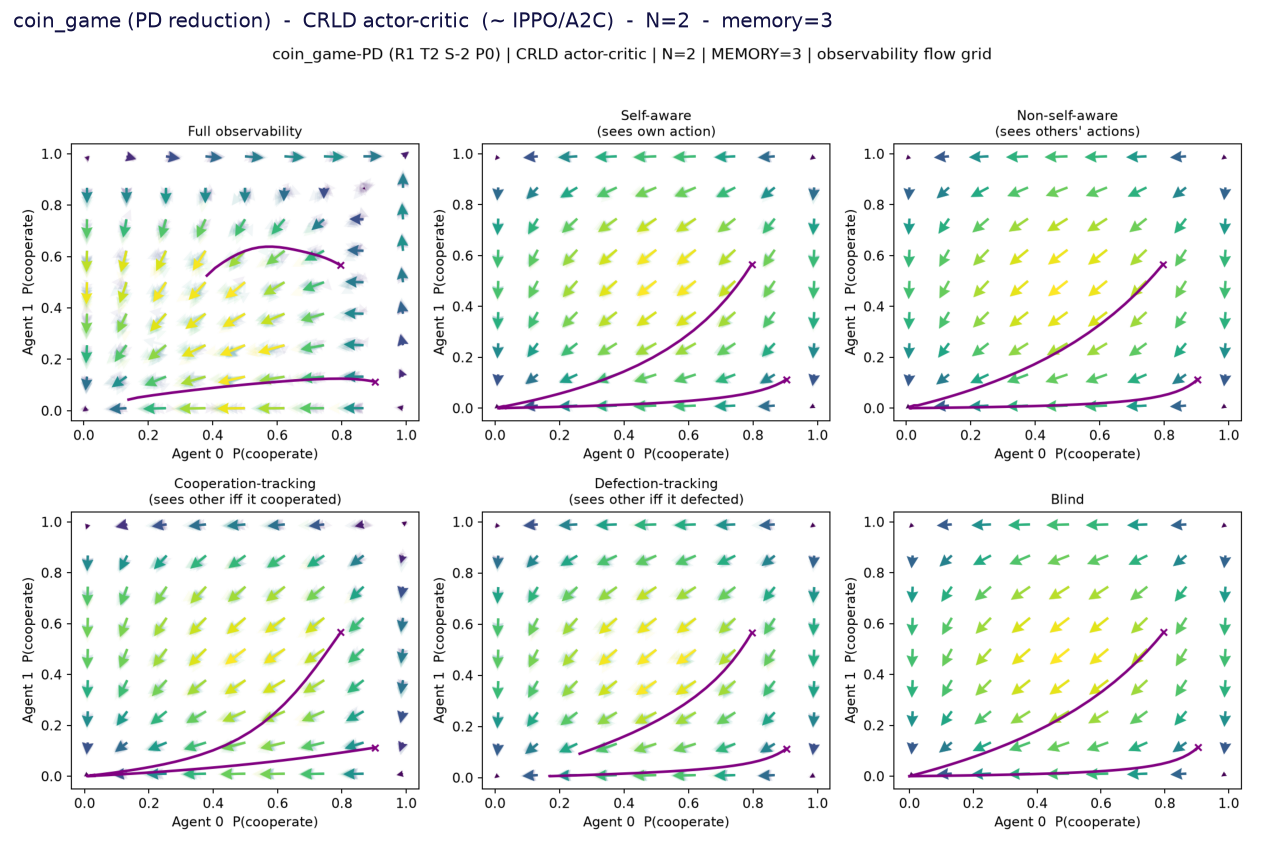

In [10]:
show('memgrid_m3_coin_ac_N2.png', 'coin_game (PD reduction)  -  CRLD actor-critic  (~ IPPO/A2C)  -  N=2  -  memory=3')

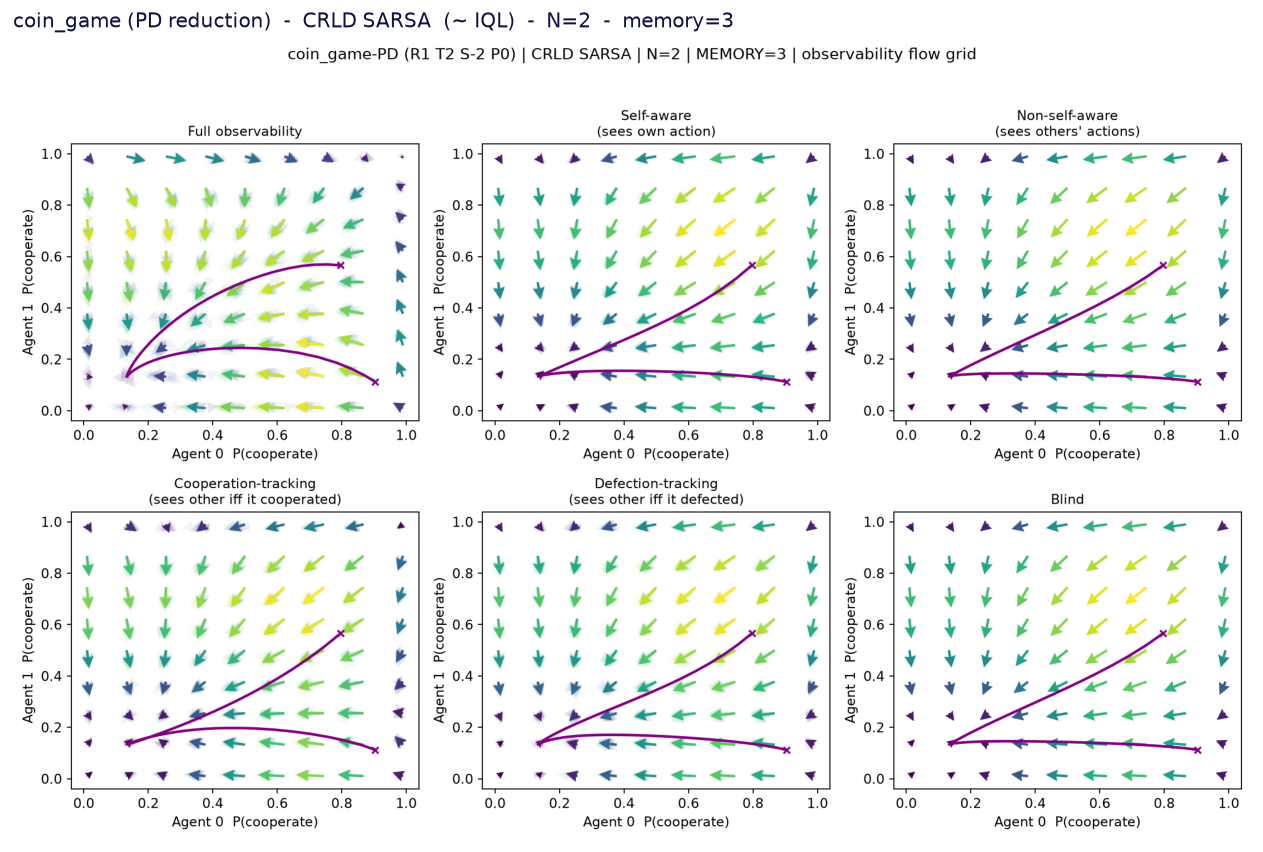

In [11]:
show('memgrid_m3_coin_sarsa_N2.png', 'coin_game (PD reduction)  -  CRLD SARSA  (~ IQL)  -  N=2  -  memory=3')

## STORM arena (N-player)

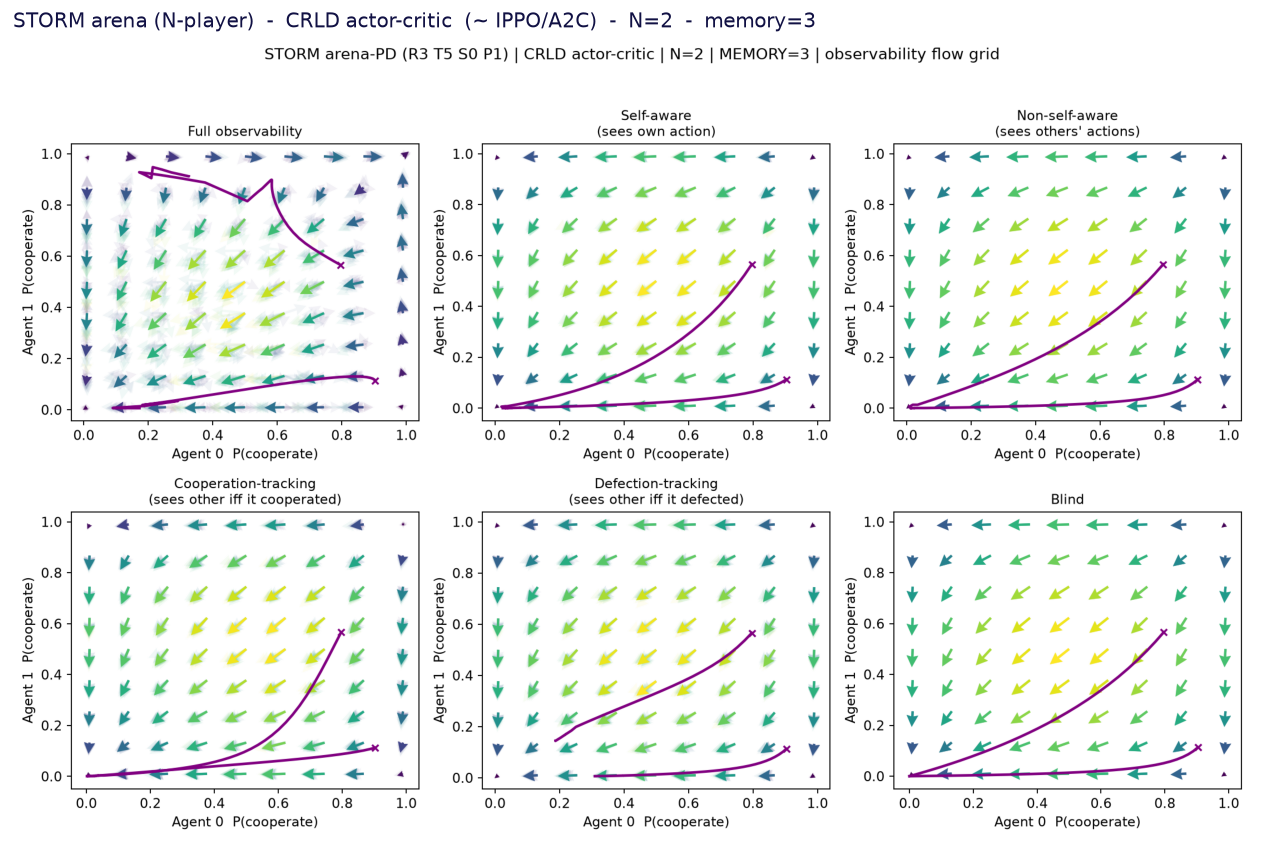

In [12]:
show('memgrid_m3_arena_ac_N2.png', 'STORM arena (N-player)  -  CRLD actor-critic  (~ IPPO/A2C)  -  N=2  -  memory=3')

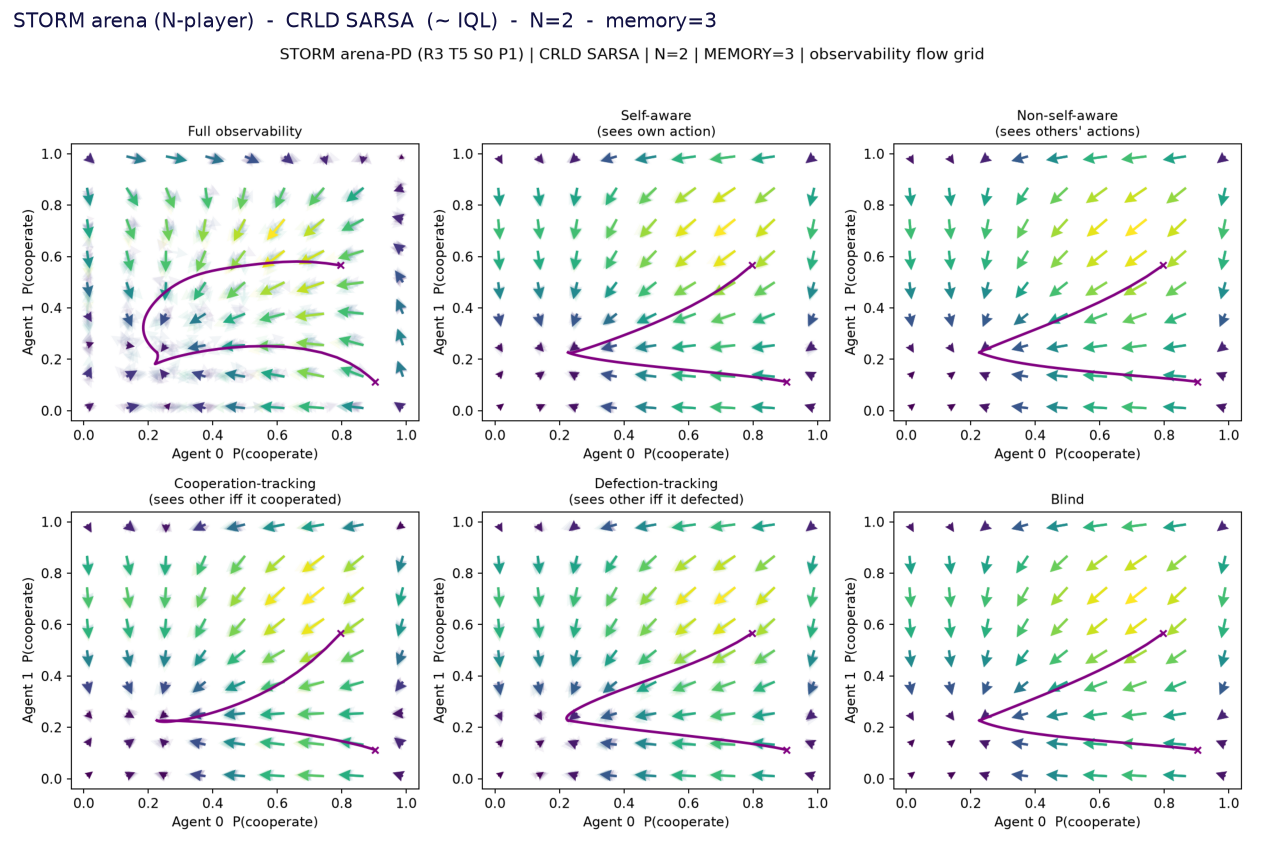

In [13]:
show('memgrid_m3_arena_sarsa_N2.png', 'STORM arena (N-player)  -  CRLD SARSA  (~ IQL)  -  N=2  -  memory=3')

## Why the arena stops at N=2 here (state-space size)

The N-player arena has $(2^N)^{3}$ states, and the CRLD einsum *intermediates*
grow faster still, so at memory-3 only **N=2** is tractable:

| arena | states at memory-3 | status |
|---|---|---|
| N=2 (shown) | 64 | cheap |
| N=3 (omitted) | 512 | too large — cancelled |
| N=4 (omitted) | 4,096 | too large |

At memory-4 the arena N=3 case (4,096 states) **OOM-killed at 16 GB and did not
finish even at 96 GB after ~30 min**; at memory-3 (512 states) it ran for 20+
min without finishing. Both were cancelled. The 2-player games and arena N=2 are
cheap by comparison.

## What memory-3 changes (vs memory-1)

Longer memory gives the agents **richer reciprocal strategies** (memory-3 variants
of tit-for-tat / win-stay-lose-shift). In the *deterministic* CRLD dynamics this can
**enlarge the cooperative basin** — e.g. the full-observability IPD develops a
trajectory that reaches mutual cooperation (1,1) under memory-3, which it did not
under memory-1 actor-critic. (Note this is the opposite of the *sampled* deep-RL
result, where extra memory mostly *hurt* because the larger observation space is
harder to learn from finite samples — the deterministic-vs-finite-batch distinction
again.)

**Caveat — why no memory-10 here.** The state space is $(2^N)^{3}$, so memory grows
the analytic tensors exponentially: 2-player memory-2 = 16 states, memory-4 = 256,
**memory-10 ≈ 1,000,000 states ⇒ tens of TB of tensors — physically infeasible.**
The memory-10 *cooperation* result (a sampled-RL cooperation curve, which avoids the
tensor blow-up) lives in the deep-RL `results_notebook` memory sweep instead.